# 🎮 Reinforcement Learning — เรียนรู้จากการลองผิดลองถูก

Notebook **เล่มที่ 4** — เสาหลักที่ 3 ของ Machine Learning ที่ยังไม่ได้แตะในสามเล่มก่อน

- **Supervised** (เล่ม 1, 3): มีเฉลยให้ดู → เรียนจับคู่ input→output
- **Unsupervised** (เล่ม 3): ไม่มีเฉลย → หาโครงสร้าง/ความผิดปกติเอง
- **Reinforcement** (เล่มนี้): ไม่มีเฉลย มีแต่ **reward** → *ลองทำ แล้วเรียนจากผลที่ได้*

RL คือกรอบคิดของการสร้าง **agent** ที่ตัดสินใจเป็น *ลำดับ* เพื่อสะสม reward ให้มากสุด —
เป็นเบื้องหลังของ AlphaGo, รถ self-driving, หุ่นยนต์ และ **RLHF** ที่ใช้ฝึก LLM (ที่ค้างไว้จากเล่ม 2)

| Part | เนื้อหา | สร้างเอง |
|---|---|---|
| 1 | RL คืออะไร + สร้าง Gridworld environment | NumPy ล้วน |
| 2 | **Q-Learning** (ตาราง) — อัลกอริทึมรากฐานของ RL | NumPy ล้วน |
| 3 | **DQN** — พอ state เยอะเกินใส่ตาราง ใช้ neural net แทน | TensorFlow |
| 4 | **REINFORCE** (policy gradient) — เรียน policy ตรง ๆ | TensorFlow |
| 5 | เชื่อมกับ **RLHF** — RL ฝึก LLM ยังไง | (แนวคิด) |
| 6 | ของจริง + สรุปทั้ง 4 เล่ม | — |

> **หัวใจของ RL:** agent อยู่ใน **state** → เลือก **action** → environment ให้ **reward** + state ใหม่ → วนซ้ำ
> เป้าหมายคือเรียน **policy** (จะทำอะไรในแต่ละ state) ที่ได้ reward สะสมระยะยาวมากสุด
> ⚠️ ทุก environment ในเล่มนี้เขียนเอง (รวมถึง physics ของ CartPole) ไม่ใช้ Gym/Gymnasium

In [1]:
# ── Setup ──
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Tahoma"
plt.rcParams["axes.unicode_minus"] = False
np.random.seed(0)

---
## Part 1 — RL คืออะไร + สร้าง Gridworld

เริ่มจากโลกที่ง่ายที่สุด: **Gridworld** — agent เป็นตัวเดินบนตาราง 4×4

- **State** = ช่องที่ agent ยืนอยู่ (เช่น (0,0))
- **Action** = เดิน 4 ทิศ (ขึ้น/ลง/ซ้าย/ขวา)
- **Reward** = ผลตอบแทนหลังเดินแต่ละก้าว:
  - ถึง 🎯 เป้าหมาย → **+10** (จบเกม)
  - ตก 💀 หลุม → **−10** (จบเกม)
  - เดินธรรมดา → **−0.1** (ค่าใช้จ่ายต่อก้าว → บีบให้รีบไปถึง ไม่เดินเล่น)
- **Episode** = 1 รอบของเกม ตั้งแต่เริ่มจนจบ (ถึงเป้า/ตกหลุม)

การออกแบบ reward (reward shaping) สำคัญมาก — มันคือ "สิ่งเดียว" ที่บอก agent ว่าอะไรดีอะไรแย่
ถ้าออกแบบผิด agent จะเรียนพฤติกรรมประหลาดได้ (เช่น ถ้าไม่มีค่าใช้จ่ายต่อก้าว มันอาจเดินวนไปเรื่อย ๆ)

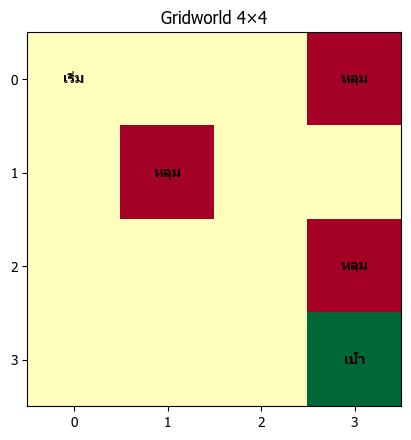

agent เริ่มที่มุมบนซ้าย ต้องหาทางไป 'เป้า' มุมล่างขวา โดยเลี่ยง 'หลุม' 3 ช่อง


In [2]:
# ── Gridworld environment เขียนเอง ──
class GridWorld:
    def __init__(self):
        self.rows, self.cols = 4, 4
        self.start = (0, 0)
        self.goal  = (3, 3)
        self.pits  = {(1, 1), (2, 3), (0, 3)}              # ช่องหลุม (จบเกม -10)
        self.actions = [(-1, 0), (1, 0), (0, -1), (0, 1)]   # ขึ้น ลง ซ้าย ขวา

    def reset(self):
        """เริ่ม episode ใหม่ -> คืน state เริ่มต้น"""
        self.pos = self.start
        return self.pos

    def step(self, a):
        """รับ action -> คืน (state ใหม่, reward, จบเกมหรือยัง)"""
        dr, dc = self.actions[a]
        r = min(max(self.pos[0] + dr, 0), self.rows - 1)    # ชนกำแพงก็อยู่ที่เดิม
        c = min(max(self.pos[1] + dc, 0), self.cols - 1)
        self.pos = (r, c)
        if self.pos == self.goal: return self.pos, 10.0, True
        if self.pos in self.pits: return self.pos, -10.0, True
        return self.pos, -0.1, False

env = GridWorld()

# ── วาดแผนที่ ──
def draw_grid(ax, env):
    grid = np.zeros((env.rows, env.cols))
    for (r, c) in env.pits: grid[r, c] = -1
    grid[env.goal] = 1
    ax.imshow(grid, cmap="RdYlGn", vmin=-1, vmax=1)
    ax.text(env.start[1], env.start[0], "เริ่ม", ha="center", va="center", fontweight="bold")
    ax.text(env.goal[1], env.goal[0], "เป้า", ha="center", va="center", fontweight="bold")
    for (r, c) in env.pits:
        ax.text(c, r, "หลุม", ha="center", va="center", fontweight="bold")
    ax.set_xticks(range(env.cols)); ax.set_yticks(range(env.rows))
    ax.set_title("Gridworld 4×4")

fig, ax = plt.subplots(figsize=(4.5, 4.5))
draw_grid(ax, env)
plt.tight_layout(); plt.show()
print("agent เริ่มที่มุมบนซ้าย ต้องหาทางไป 'เป้า' มุมล่างขวา โดยเลี่ยง 'หลุม' 3 ช่อง")

---
## Part 2 — Q-Learning: อัลกอริทึมรากฐานของ RL

ไอเดียหลัก: เรียน **Q-value** `Q(state, action)` = "ถ้าอยู่ state นี้แล้วทำ action นี้ จะได้ reward รวมระยะยาวประมาณเท่าไร"
ถ้ารู้ Q ครบทุกคู่ การเล่นก็แค่ "เลือก action ที่ Q สูงสุด" ในแต่ละ state

เก็บ Q ไว้ใน **ตาราง** (4×4 ช่อง × 4 action) เริ่มจาก 0 ทั้งหมด แล้วอัปเดตด้วย **สมการ Bellman**:

$$Q(s,a) \leftarrow Q(s,a) + \alpha\,\big[\underbrace{r + \gamma \max_{a'} Q(s',a')}_{\text{ค่าที่ควรเป็น}} - \underbrace{Q(s,a)}_{\text{ค่าปัจจุบัน}}\big]$$

- $\alpha$ (learning rate) = ขยับเข้าหาค่าใหม่เร็วแค่ไหน
- $\gamma$ (discount factor) = ให้น้ำหนัก reward อนาคตแค่ไหน (0.95 = มองไกล)
- $r + \gamma \max Q(s',a')$ = reward ตอนนี้ + ค่าที่ดีสุดที่ทำได้จาก state ถัดไป

**Explore vs Exploit** — ปัญหาคลาสสิกของ RL: จะ *ลองของใหม่* (explore) หรือ *เลือกของที่รู้ว่าดี* (exploit)?
ใช้ **ε-greedy**: ด้วยความน่าจะเป็น ε สุ่มมั่ว (สำรวจ), ที่เหลือเลือกตัวที่ Q สูงสุด
เริ่ม ε สูง (สำรวจเยอะตอนยังไม่รู้อะไร) แล้วค่อย ๆ ลด (พอเก่งแล้วก็ใช้ความรู้)

reward เฉลี่ย: ช่วงต้น -7.9  ->  ช่วงท้าย 8.9


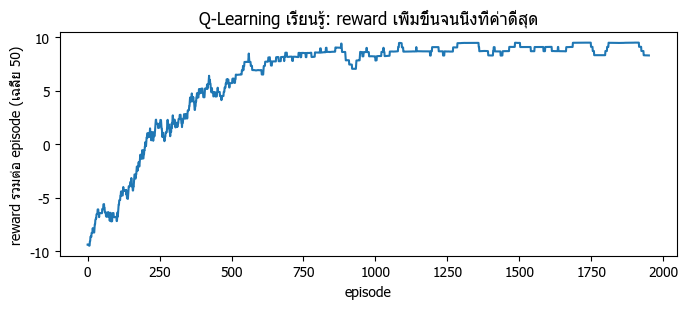

In [3]:
# ── Q-Learning: train ด้วย ε-greedy ──
np.random.seed(0)
env = GridWorld()
Q = np.zeros((env.rows, env.cols, 4))        # ตาราง Q เริ่มจาก 0

alpha, gamma = 0.1, 0.95
epsilon = 1.0
reward_history = []

for episode in range(2000):
    s = env.reset(); done = False; total = 0
    for _ in range(100):                                   # จำกัดความยาว episode กันวนไม่จบ
        # --- ε-greedy: สุ่มสำรวจ หรือ เลือกตัวที่ดีสุด ---
        if np.random.rand() < epsilon:
            a = np.random.randint(4)
        else:
            a = int(np.argmax(Q[s[0], s[1]]))

        s2, r, done = env.step(a); total += r

        # --- Bellman update ---
        best_next = 0 if done else np.max(Q[s2[0], s2[1]])
        Q[s[0], s[1], a] += alpha * (r + gamma * best_next - Q[s[0], s[1], a])
        s = s2
        if done: break

    epsilon = max(0.05, epsilon * 0.998)                   # ค่อย ๆ ลดการสำรวจ
    reward_history.append(total)

print(f"reward เฉลี่ย: ช่วงต้น {np.mean(reward_history[:100]):.1f}  ->  ช่วงท้าย {np.mean(reward_history[-100:]):.1f}")

# moving average ให้เส้นเรียบ
ma = np.convolve(reward_history, np.ones(50)/50, mode="valid")
plt.figure(figsize=(7, 3.2))
plt.plot(ma)
plt.xlabel("episode"); plt.ylabel("reward รวมต่อ episode (เฉลี่ย 50)")
plt.title("Q-Learning เรียนรู้: reward เพิ่มขึ้นจนนิ่งที่ค่าดีสุด")
plt.tight_layout(); plt.show()

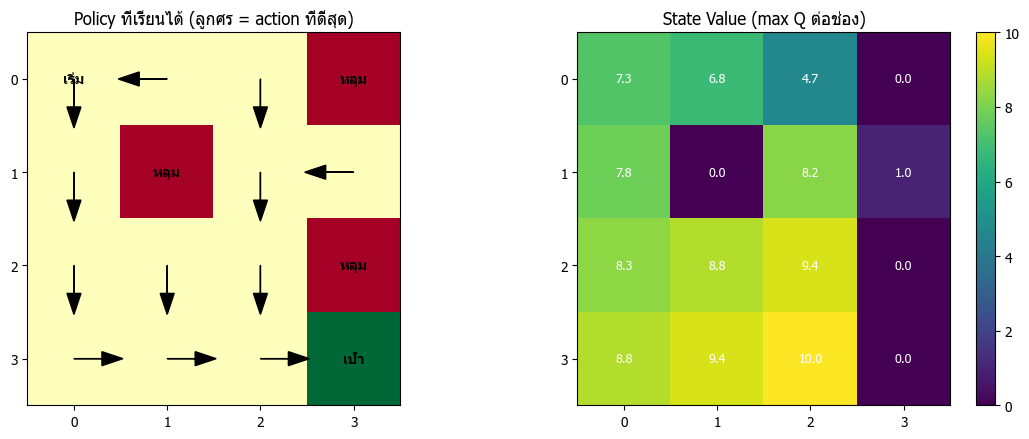

เดินตาม policy: [(0, 0), (1, 0), (2, 0), (3, 0), (3, 1), (3, 2), (3, 3)]
ถึงเป้าหมายใน 6 ก้าว


In [4]:
# ── ดู policy ที่เรียนได้: ลูกศรชี้ action ที่ดีสุดในแต่ละช่อง ──
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# (ซ้าย) policy เป็นลูกศร
draw_grid(axes[0], env)
# (dr,dc) -> ทิศลูกศรในภาพ: แกน y ของ imshow ชี้ลง => up(dr=-1) ให้ลูกศรชี้ขึ้น dy=+1 (ใช้ค่าลบของ dr)
dir_uv = {0: (0, 1), 1: (0, -1), 2: (-1, 0), 3: (1, 0)}    # ขึ้น ลง ซ้าย ขวา -> (dx, dy)
for r in range(env.rows):
    for c in range(env.cols):
        if (r, c) == env.goal or (r, c) in env.pits: continue
        a = int(np.argmax(Q[r, c]))
        dx, dy = dir_uv[a]
        axes[0].arrow(c, r, dx * 0.3, -dy * 0.3, head_width=0.15, color="black")
axes[0].set_title("Policy ที่เรียนได้ (ลูกศร = action ที่ดีสุด)")

# (ขวา) state value = max Q ของแต่ละช่อง (ยิ่งใกล้เป้ายิ่งสูง)
V = Q.max(axis=2)
im = axes[1].imshow(V, cmap="viridis")
for r in range(env.rows):
    for c in range(env.cols):
        axes[1].text(c, r, f"{V[r,c]:.1f}", ha="center", va="center", color="white", fontsize=9)
axes[1].set_title("State Value (max Q ต่อช่อง)")
axes[1].set_xticks(range(4)); axes[1].set_yticks(range(4))
plt.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout(); plt.show()

# เดินตาม policy ที่เรียนได้
s = env.reset(); path = [s]
for _ in range(20):
    s, r, done = env.step(int(np.argmax(Q[s[0], s[1]]))); path.append(s)
    if done: break
print(f"เดินตาม policy: {path}")
print(f"ถึงเป้าหมายใน {len(path)-1} ก้าว" if path[-1] == env.goal else "ยังไปไม่ถึง")

> **ข้อจำกัดของ Q-table:** ที่นี่มีแค่ 16 ช่อง × 4 action = 64 ค่า เก็บในตารางสบาย
> แต่ถ้า state เป็น**ค่าต่อเนื่อง** (เช่น ตำแหน่ง+ความเร็วของวัตถุ) หรือมีเป็นล้าน ๆ state (เช่นภาพหน้าจอเกม)
> ตารางจะใหญ่จนเก็บไม่ไหว และ agent ไม่มีทางไปเจอทุก state ครบ
>
> ทางออก: ใช้ **neural network ประมาณค่า Q** แทนตาราง — นั่นคือ **DQN** ใน Part ถัดไป

---
## Part 3 — Deep Q-Network (DQN): เมื่อ State เยอะเกินกว่าจะใส่ตาราง

**DQN** แทนตาราง $Q(s,a)$ ด้วย **neural network** ที่รับ state แล้วทำนาย Q ของทุก action
ตอนนี้ state เป็นเวกเตอร์ต่อเนื่องได้ และ network ก็ *generalize* ไปยัง state ที่ไม่เคยเจอเป๊ะ ๆ ได้

ทดสอบกับปัญหาคลาสสิก **CartPole**: คุมแรงซ้าย/ขวาให้เสาที่ตั้งบนรถเข็น**ไม่ล้ม** นานที่สุด
- **State** = 4 ค่าต่อเนื่อง: ตำแหน่งรถ, ความเร็วรถ, มุมเสา, ความเร็วเชิงมุมของเสา
- **Action** = ผลักซ้าย (0) หรือ ขวา (1)
- **Reward** = +1 ทุก step ที่เสายังไม่ล้ม (จบเมื่อเสาเอียงเกิน 12° หรือรถออกนอกจอ; สูงสุด 200)

DQN เพิ่ม 2 กลไกสำคัญที่ทำให้ train เสถียร:
- **Experience Replay** — เก็บประสบการณ์ `(s, a, r, s')` ลง buffer แล้วสุ่มมา train เป็น batch
  (ตัดความสัมพันธ์ระหว่าง step ที่ติดกัน → เหมือนมี dataset ที่ i.i.d. กว่า)
- **Target Network** — ใช้ network สำเนา (อัปเดตช้า ๆ) คำนวณ "ค่าที่ควรเป็น" → กันการไล่ตามเป้าที่ขยับตลอดจนพัง

In [5]:
# ── CartPole: เขียน physics เอง (สมการมาตรฐาน ไม่ใช้ Gym) ──
class CartPole:
    g = 9.8; mc = 1.0; mp = 0.1; l = 0.5; force_mag = 10.0; tau = 0.02   # ค่าคงที่ฟิสิกส์มาตรฐาน
    def __init__(self):
        self.total_mass = self.mc + self.mp
        self.polemass_length = self.mp * self.l

    def reset(self):
        self.state = np.random.uniform(-0.05, 0.05, 4).astype(np.float32)   # เริ่มเกือบตั้งตรง
        self.steps = 0
        return self.state.copy()

    def step(self, a):
        x, x_dot, th, th_dot = self.state
        force = self.force_mag if a == 1 else -self.force_mag
        ct, st = np.cos(th), np.sin(th)
        # สมการการเคลื่อนที่ของ cart-pole
        temp = (force + self.polemass_length * th_dot**2 * st) / self.total_mass
        th_acc = (self.g * st - ct * temp) / (self.l * (4/3 - self.mp * ct**2 / self.total_mass))
        x_acc = temp - self.polemass_length * th_acc * ct / self.total_mass
        # อัปเดตสถานะแบบ Euler
        x += self.tau * x_dot;      x_dot += self.tau * x_acc
        th += self.tau * th_dot;    th_dot += self.tau * th_acc
        self.state = np.array([x, x_dot, th, th_dot], dtype=np.float32)
        self.steps += 1
        done = bool(abs(x) > 2.4 or abs(th) > 0.2095 or self.steps >= 200)   # ล้ม/ออกนอกจอ/ครบ 200
        return self.state.copy(), 1.0, done

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
tf.get_logger().setLevel("ERROR")
print("CartPole พร้อม | สุ่ม action ไปเรื่อย ๆ เสาจะล้มเร็วมาก:")

# ทดสอบ: เล่นมั่ว ๆ ดูว่าอยู่ได้กี่ step
env_cp = CartPole(); s = env_cp.reset(); done = False; steps = 0
while not done:
    s, r, done = env_cp.step(np.random.randint(2)); steps += 1
print(f"   เล่นแบบสุ่ม: เสาล้มใน {steps} step (เป้าหมายคือคุมให้ถึง 200)")

CartPole พร้อม | สุ่ม action ไปเรื่อย ๆ เสาจะล้มเร็วมาก:
   เล่นแบบสุ่ม: เสาล้มใน 25 step (เป้าหมายคือคุมให้ถึง 200)


In [6]:
# ── DQN: train agent ให้คุมเสา (~3-4 นาทีบน CPU) ──
keras.utils.set_random_seed(0); np.random.seed(0)
env_cp = CartPole()

def build_qnet():
    return keras.Sequential([keras.Input((4,)),
                             layers.Dense(24, activation="relu"),
                             layers.Dense(24, activation="relu"),
                             layers.Dense(2)])               # output = Q ของ 2 action

qnet   = build_qnet()
target = build_qnet(); target.set_weights(qnet.get_weights())   # target network (สำเนา)
opt = keras.optimizers.Adam(1e-3)

@tf.function                                                  # คอมไพล์ให้ train เร็ว
def train_step(states, actions, targets):
    with tf.GradientTape() as tape:
        q = qnet(states, training=True)
        idx = tf.stack([tf.range(tf.shape(actions)[0]), actions], axis=1)
        q_taken = tf.gather_nd(q, idx)                        # Q ของ action ที่เลือกจริง
        loss = tf.reduce_mean((q_taken - targets) ** 2)
    opt.apply_gradients(zip(tape.gradient(loss, qnet.trainable_variables), qnet.trainable_variables))

buffer = []                                                   # experience replay
epsilon, gamma = 1.0, 0.99
dqn_history = []; step = 0

for ep in range(300):
    s = env_cp.reset(); done = False; total = 0
    while not done:
        # ε-greedy (ใช้ network ทำนาย Q)
        if np.random.rand() < epsilon:
            a = np.random.randint(2)
        else:
            a = int(np.argmax(qnet(s[None], training=False).numpy()[0]))
        s2, r, done = env_cp.step(a)
        buffer.append((s, a, r, s2, float(done))); s = s2; total += 1; step += 1
        if len(buffer) > 10000: buffer.pop(0)

        # สุ่ม batch จาก buffer มา train
        if len(buffer) >= 64:
            ix = np.random.randint(0, len(buffer), 64); b = [buffer[i] for i in ix]
            ss  = np.array([x[0] for x in b], dtype=np.float32)
            aa  = np.array([x[1] for x in b], dtype=np.int32)
            rr  = np.array([x[2] for x in b], dtype=np.float32)
            s2s = np.array([x[3] for x in b], dtype=np.float32)
            dd  = np.array([x[4] for x in b], dtype=np.float32)
            q_next = target(s2s, training=False).numpy()                  # ใช้ target net คำนวณค่าที่ควรเป็น
            tg = (rr + gamma * np.max(q_next, axis=1) * (1 - dd)).astype(np.float32)
            train_step(ss, tf.constant(aa), tf.constant(tg))

    epsilon = max(0.02, epsilon * 0.98)
    if ep % 5 == 0: target.set_weights(qnet.get_weights())     # sync target ทุก 5 episode
    dqn_history.append(total)
    if ep % 30 == 0:
        print(f"   episode {ep:3d}: อยู่ได้ {total:3d} step (ε={epsilon:.2f})")

print(f"\nDQN: ช่วงต้น {np.mean(dqn_history[:20]):.0f} -> ช่วงท้าย {np.mean(dqn_history[-30:]):.0f} step "
      f"(ดีสุด {max(dqn_history)}/200)")

   episode   0: อยู่ได้  12 step (ε=0.98)


   episode  30: อยู่ได้  23 step (ε=0.53)


   episode  60: อยู่ได้ 200 step (ε=0.29)


   episode  90: อยู่ได้ 200 step (ε=0.16)


   episode 120: อยู่ได้ 200 step (ε=0.09)


...

   episode 180: อยู่ได้ 155 step (ε=0.03)


   episode 210: อยู่ได้ 170 step (ε=0.02)


   episode 240: อยู่ได้ 129 step (ε=0.02)


   episode 270: อยู่ได้ 200 step (ε=0.02)



DQN: ช่วงต้น 22 -> ช่วงท้าย 163 step (ดีสุด 200/200)


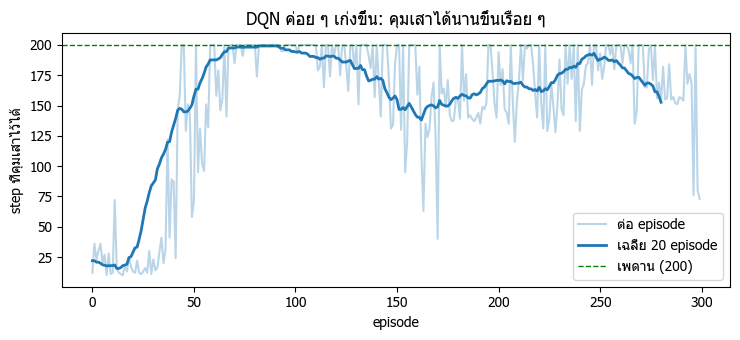

เส้นจะแกว่ง (RL ขึ้นชื่อเรื่องความไม่นิ่ง) แต่แนวโน้มชัดว่าเรียนรู้ได้


In [7]:
# ── เส้นเรียนรู้ของ DQN ──
plt.figure(figsize=(7.5, 3.5))
plt.plot(dqn_history, alpha=0.3, color="tab:blue", label="ต่อ episode")
ma = np.convolve(dqn_history, np.ones(20)/20, mode="valid")
plt.plot(range(len(ma)), ma, color="tab:blue", lw=2, label="เฉลี่ย 20 episode")
plt.axhline(200, color="green", ls="--", lw=1, label="เพดาน (200)")
plt.xlabel("episode"); plt.ylabel("step ที่คุมเสาไว้ได้")
plt.title("DQN ค่อย ๆ เก่งขึ้น: คุมเสาได้นานขึ้นเรื่อย ๆ")
plt.legend(); plt.tight_layout(); plt.show()
print("เส้นจะแกว่ง (RL ขึ้นชื่อเรื่องความไม่นิ่ง) แต่แนวโน้มชัดว่าเรียนรู้ได้")

---
## Part 4 — REINFORCE: เรียน Policy ตรง ๆ (Policy Gradient)

DQN เรียน *ค่า* (Q) แล้วค่อยเลือก action จากค่านั้น — เป็นตระกูล **value-based**
อีกตระกูลคือ **policy-based**: ให้ network พ่น **ความน่าจะเป็นของแต่ละ action** ออกมาตรง ๆ แล้วสุ่มเล่นตามนั้น

**REINFORCE** เป็น policy gradient ที่ง่ายที่สุด ไอเดียสุดแสนสัญชาตญาณ:
> เล่นจบ 1 episode → ถ้าได้ reward รวมเยอะ ก็ **เพิ่มความน่าจะเป็น**ของ action ที่เพิ่งทำไป; ถ้าน้อยก็ลด

สมการอัปเดต (ดันให้ทำ action ที่นำไปสู่ผลตอบแทนสูง):

$$\nabla_\theta J = \mathbb{E}\big[\, G_t \cdot \nabla_\theta \log \pi_\theta(a_t \mid s_t)\,\big]$$

- $\pi_\theta(a|s)$ = policy (ความน่าจะเป็นของ action) ที่ network พ่นออกมา
- $G_t$ = reward รวม (discounted) นับจากเวลา $t$ ไปจนจบ episode = "action นี้ดีแค่ไหน"
- ดังนั้น action ที่ตามด้วยผลดี → $\log\pi$ ถูกดันขึ้น → ครั้งหน้ามีโอกาสถูกเลือกมากขึ้น

In [8]:
# ── REINFORCE: train policy network โดยตรง (~1.5 นาที) ──
keras.utils.set_random_seed(1); np.random.seed(1)
env_cp = CartPole()

policy = keras.Sequential([keras.Input((4,)),
                           layers.Dense(32, activation="relu"),
                           layers.Dense(2, activation="softmax")])    # output = ความน่าจะเป็น 2 action
opt_pg = keras.optimizers.Adam(5e-3)
gamma = 0.99

@tf.function
def update_policy(states, actions, returns):
    with tf.GradientTape() as tape:
        probs = policy(states, training=True)
        idx = tf.stack([tf.range(tf.shape(actions)[0]), actions], axis=1)
        log_prob = tf.math.log(tf.gather_nd(probs, idx) + 1e-8)
        loss = -tf.reduce_mean(log_prob * returns)            # ดัน action ที่ return สูงให้น่าจะเป็นมากขึ้น
    opt_pg.apply_gradients(zip(tape.gradient(loss, policy.trainable_variables), policy.trainable_variables))

reinforce_history = []
for ep in range(400):
    s = env_cp.reset(); done = False
    S, A, R = [], [], []
    while not done:                                            # เล่นจนจบ 1 episode ก่อน
        p = policy(s[None], training=False).numpy()[0]
        a = int(np.random.choice(2, p=p))                     # สุ่ม action ตามความน่าจะเป็น
        s2, r, done = env_cp.step(a)
        S.append(s); A.append(a); R.append(r); s = s2

    # คำนวณ return (discounted) ของแต่ละ step แล้ว normalize
    G = np.zeros(len(R), dtype=np.float32); running = 0.0
    for t in reversed(range(len(R))):
        running = R[t] + gamma * running; G[t] = running
    G = (G - G.mean()) / (G.std() + 1e-8)

    update_policy(np.array(S, dtype=np.float32), tf.constant(np.array(A, dtype=np.int32)), tf.constant(G))
    reinforce_history.append(len(R))
    if ep % 50 == 0:
        print(f"   episode {ep:3d}: เฉลี่ย 20 ล่าสุด {np.mean(reinforce_history[-20:]):.0f} step")

print(f"\nREINFORCE: ช่วงต้น {np.mean(reinforce_history[:30]):.0f} -> ช่วงท้าย {np.mean(reinforce_history[-30:]):.0f} step "
      f"(ดีสุด {max(reinforce_history)}/200)")

   episode   0: เฉลี่ย 20 ล่าสุด 13 step


   episode  50: เฉลี่ย 20 ล่าสุด 35 step


   episode 100: เฉลี่ย 20 ล่าสุด 60 step


   episode 150: เฉลี่ย 20 ล่าสุด 87 step


   episode 200: เฉลี่ย 20 ล่าสุด 160 step


   episode 250: เฉลี่ย 20 ล่าสุด 174 step


   episode 300: เฉลี่ย 20 ล่าสุด 194 step


   episode 350: เฉลี่ย 20 ล่าสุด 193 step



REINFORCE: ช่วงต้น 23 -> ช่วงท้าย 159 step (ดีสุด 200/200)


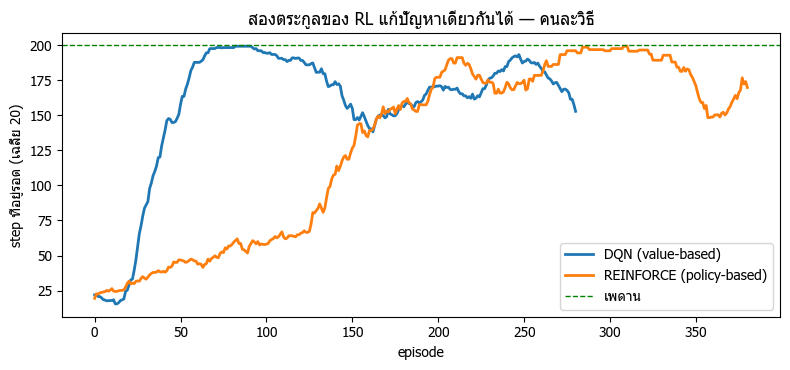

• DQN: เรียน 'ค่า' ของ action แล้วเลือกตัวดีสุด — sample-efficient แต่ปรับ hyperparameter ยาก
• REINFORCE: เรียน 'นโยบาย' ตรง ๆ — เข้าใจง่าย แต่ผลแกว่าง (variance สูง)
• ของจริงยุคใหม่ (เช่น PPO ที่ใช้ใน RLHF) ผสมจุดแข็งของทั้งสองเข้าด้วยกัน


In [9]:
# ── เทียบ DQN vs REINFORCE ──
plt.figure(figsize=(8, 3.8))
for hist, name, color in [(dqn_history, "DQN (value-based)", "tab:blue"),
                          (reinforce_history, "REINFORCE (policy-based)", "tab:orange")]:
    ma = np.convolve(hist, np.ones(20)/20, mode="valid")
    plt.plot(range(len(ma)), ma, label=name, color=color, lw=2)
plt.axhline(200, color="green", ls="--", lw=1, label="เพดาน")
plt.xlabel("episode"); plt.ylabel("step ที่อยู่รอด (เฉลี่ย 20)")
plt.title("สองตระกูลของ RL แก้ปัญหาเดียวกันได้ — คนละวิธี")
plt.legend(); plt.tight_layout(); plt.show()

print("• DQN: เรียน 'ค่า' ของ action แล้วเลือกตัวดีสุด — sample-efficient แต่ปรับ hyperparameter ยาก")
print("• REINFORCE: เรียน 'นโยบาย' ตรง ๆ — เข้าใจง่าย แต่ผลแกว่าง (variance สูง)")
print("• ของจริงยุคใหม่ (เช่น PPO ที่ใช้ใน RLHF) ผสมจุดแข็งของทั้งสองเข้าด้วยกัน")

---
## Part 5 — เชื่อมกับ RLHF: RL ฝึก LLM ได้ยังไง

ในเล่ม 2 เราพูดถึง **RLHF (Reinforcement Learning from Human Feedback)** ค้างไว้ — ตอนนี้มีเครื่องมือครบจะเข้าใจมันแล้ว

จำกรอบ RL ได้ไหม: *agent → action → reward → เรียนรู้* ลองจับคู่กับการฝึก LLM:

| แนวคิด RL | ใน RLHF (ฝึก LLM) |
|---|---|
| **agent** | ตัว LLM เอง |
| **state** | บทสนทนา/prompt ที่เห็นมาจนถึงตอนนี้ |
| **action** | เลือก token ตัวถัดไปจะพ่นอะไร |
| **reward** | คะแนนจาก **reward model** ที่เรียนจากความชอบของคน |
| **policy** | การแจกแจงความน่าจะเป็นของ token (ก็คือตัว LLM นั่นเอง!) |

ขั้นตอนของ RLHF (ย่อ):
1. **เก็บความชอบของคน** — ให้คนจัดอันดับคำตอบหลาย ๆ แบบ ว่าอันไหนดีกว่า
2. **เทรน reward model** — โมเดลที่ทำนาย "คะแนนความพอใจของคน" ต่อคำตอบหนึ่ง ๆ (นี่คือ supervised learning)
3. **ปรับ LLM ด้วย RL** — ใช้ **PPO** (policy gradient รุ่นพัฒนาต่อจาก REINFORCE ใน Part 4!) ดันให้ LLM
   พ่นคำตอบที่ได้คะแนนจาก reward model สูง ๆ

> นี่คือขั้นที่เปลี่ยน "base model ที่แค่ทายคำถัดไป" (เล่ม 2 Part 5) ให้กลายเป็น
> "ผู้ช่วยที่สุภาพ เป็นประโยชน์ และปลอดภัย" — **policy gradient ที่คุณเพิ่งเขียนเองใน Part 4 คือแกนของกระบวนการนี้**

---
## Part 6 — ของจริง + สรุปทั้ง 4 เล่ม

### 🌍 RL ในโลกจริง
- **เล่นเกมเหนือมนุษย์** — AlphaGo/AlphaZero (โกะ, หมากรุก), DQN เล่น Atari จากภาพหน้าจอดิบ ๆ
- **หุ่นยนต์** — สอนหุ่นเดิน/หยิบจับของ (แต่ sim-to-real ยากเพราะโลกจริงไม่เหมือน simulator)
- **ระบบจริง** — จัดการพลังงาน data center, แนะนำคอนเทนต์, ปรับ LLM (RLHF)

### ⚙️ เครื่องมือจริง (เมื่อพร้อมไปต่อ)
- **Gymnasium** (เดิม OpenAI Gym) — มาตรฐานของ RL environment (CartPole ที่เราเขียนเองก็มาจากที่นี่)
- **Stable-Baselines3** — รวมอัลกอริทึมพร้อมใช้ (DQN, PPO, SAC) ที่ tune มาดีแล้ว
- **PPO / A2C / SAC** — อัลกอริทึมยุคใหม่ที่เสถียรและ sample-efficient กว่าที่เราเขียน

### ⚠️ ความท้าทายของ RL
- **Sample efficiency** — RL ต้องลองเป็นล้าน ๆ ครั้ง (แพงมากถ้า "การลอง" คือหุ่นยนต์จริงหรือเงินจริง)
- **Reward design** — ออกแบบ reward ผิดนิดเดียว agent หาช่องโกงเจอ (reward hacking)
- **ความไม่นิ่ง** — training แกว่งง่าย (เห็นได้จากเส้นเรียนรู้ใน Part 3–4)
- **Exploration** — ในโลกที่ reward เบาบาง (กว่าจะได้ reward ต้องทำถูกหลายขั้น) การสำรวจให้เจอเป็นเรื่องยากมาก

---

### 🎓 สรุปทั้ง 4 เล่ม — ครบทุกเสาหลักของ ML

| เล่ม | Paradigm | เดินทางจาก → ถึง |
|---|---|---|
| **1 — ML Fundamentals** | supervised + deep learning | neuron เดี่ยว → CNN → attention → mini GPT |
| **2 — LLM Deep Dive** | self-supervised / generative | tokenizer → pretrain → fine-tune |
| **3 — ML × Network Security** | supervised + **unsupervised** | classical ML → anomaly detection → adversarial |
| **4 — Reinforcement Learning** | **reinforcement** | gridworld → Q-learning → DQN → REINFORCE → RLHF |

> 4 เล่มนี้ครอบคลุม **3 เสาหลักของ ML ครบทุกตัว** (supervised / unsupervised / reinforcement)
> บวกกับ deep learning, generative models และมุมมอง security
>
> และทั้งหมดยังตั้งอยู่บนแนวคิดเดียวจากหน้าแรกของเล่ม 1: **เรียนรู้ = ลองทำ → วัดผล → ปรับปรุง → วนซ้ำ**
> ต่างกันแค่ "ปรับจากอะไร" — จาก label (supervised), จากโครงสร้างข้อมูล (unsupervised), หรือจาก reward (reinforcement)

### แหล่งเรียนรู้ต่อ
- 📚 Sutton & Barto — *Reinforcement Learning: An Introduction* (คัมภีร์ของวงการ ฟรีออนไลน์)
- 🎬 David Silver — *RL Course* (DeepMind, YouTube)
- 🎮 **Gymnasium** + **Stable-Baselines3** docs — ลองอัลกอริทึมจริงกับ environment มาตรฐาน
- 📄 *Proximal Policy Optimization* (PPO, 2017) — อัลกอริทึมเบื้องหลัง RLHF